In [ ]:
import sys
sys.path.append(r"C:\Users\Blen\insurance-risk-analytics\insurance-risk-analytics\src")
from data_loader import load_data, basic_cleaning

In [4]:
print("=== AVAILABLE COLUMNS IN DATASET ===")
print(df.columns.tolist())

print("\n=== FIRST 5 ROWS ===")
print(df.head())

=== AVAILABLE COLUMNS IN DATASET ===
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims', 'LossRatio', 'Margin']

=== FIRST 5 ROWS ===
   UnderwrittenCoverID  PolicyID TransactionMonth  IsVATRegistered  \
0               145249     12827       2015-03

Current Directory: c:\Users\Blen\insurance-risk-analytics\insurance-risk-analytics\notebooks
Python Path: ['C:\\Users\\Blen\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\Blen\\AppData\\Local\\Programs\\Python\\Python311\\DLLs', 'C:\\Users\\Blen\\AppData\\Local\\Programs\\Python\\Python311\\Lib', 'C:\\Users\\Blen\\AppData\\Local\\Programs\\Python\\Python311', 'c:\\Users\\Blen\\insurance-risk-analytics\\insurance-risk-analytics\\.venv', '', 'c:\\Users\\Blen\\insurance-risk-analytics\\insurance-risk-analytics\\.venv\\Lib\\site-packages', 'c:\\Users\\Blen\\insurance-risk-analytics\\insurance-risk-analytics\\.venv\\Lib\\site-packages\\win32', 'c:\\Users\\Blen\\insurance-risk-analytics\\insurance-risk-analytics\\.venv\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\Blen\\insurance-risk-analytics\\insurance-risk-analytics\\.venv\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\Blen\\insurance-risk-analytics\\insurance-risk-analytics\\notebooks', 'c:\\Users\\Blen\\insuran

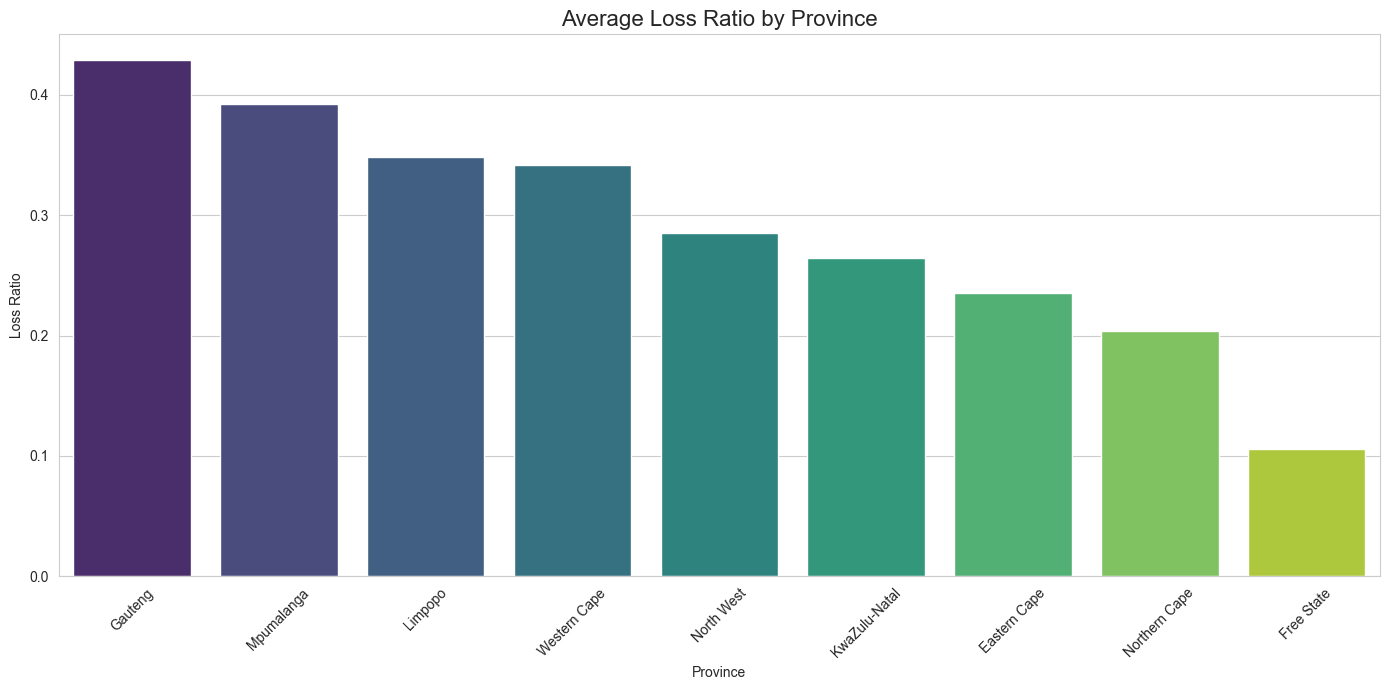

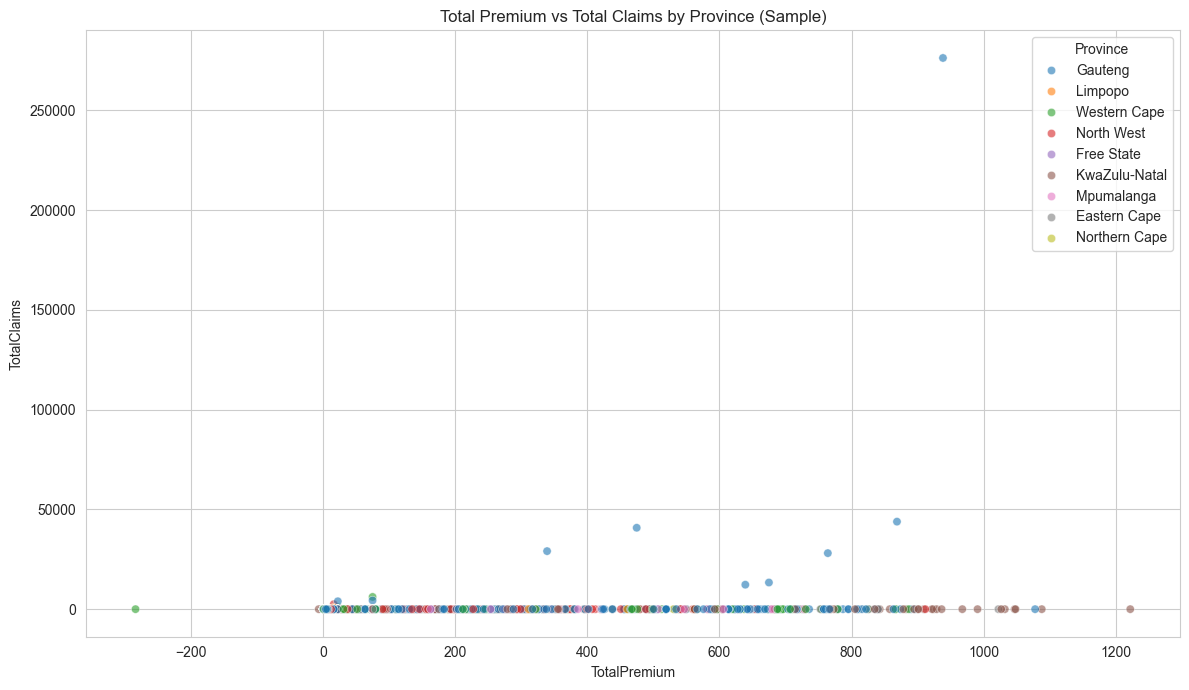

KeyError: 'Make'

<Figure size 1200x700 with 0 Axes>

In [ ]:
# ================================================
# 01_eda.ipynb - FINAL WORKING VERSION
# ================================================

# === FIX PATH & IMPORTS ===
import sys
import os
sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'src'))
sys.path.append(os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

from data_loader import load_data, basic_cleaning

# ====================== LOAD DATA ======================
print("="*70)
print("LOADING INSURANCE DATA")
print("="*70)

df = load_data()
df = basic_cleaning(df)

print(f"\n✅ Dataset Shape: {df.shape}")

# ====================== SUMMARY ======================
print(f"\nOverall Loss Ratio: {df['LossRatio'].mean():.4f}")

missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nTop Missing Values (%):")
print(missing.head(10))

# ====================== VISUALIZATIONS ======================
print("\nGenerating Plots...")

# 1. Loss Ratio by Province
plt.figure(figsize=(14, 7))
province_lr = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
sns.barplot(x=province_lr.index, y=province_lr.values, palette='viridis')
plt.title('Average Loss Ratio by Province', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('Loss Ratio')
plt.tight_layout()
plt.show()

# 2. Premium vs Claims
plt.figure(figsize=(12, 7))
sample = df.sample(5000, random_state=42)
sns.scatterplot(data=sample, x='TotalPremium', y='TotalClaims', hue='Province', alpha=0.6)
plt.title('Total Premium vs Total Claims by Province (Sample)')
plt.tight_layout()
plt.show()

# 3. Top 10 Vehicle Makes (FIXED - using 'make')
plt.figure(figsize=(12, 7))
top_makes = df.groupby('make')['TotalClaims'].sum().nlargest(10)
sns.barplot(x=top_makes.values, y=top_makes.index, palette='mako')
plt.title('Top 10 Vehicle Makes by Total Claims')
plt.xlabel('Total Claims Amount')
plt.tight_layout()
plt.show()

# 4. Policies by Gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title('Number of Policies by Gender')
plt.ylabel('Count')
plt.show()

# 5. Outliers in TotalClaims
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='TotalClaims')
plt.title('Outliers Detection - Total Claims')
plt.show()

print("\n🎉 EDA Notebook Completed Successfully!")